# Практична робота №7: Візуалізація: Figure і Axes, підписи, гістограма, boxplot, діаграма розсіювання

- **Дисципліна:** Аналіз даних та математичне моделювання
- **Студент:** Хрустовський Павло
- **Група:** ІТ-42
- **Варіант:** 2
  - **Місто:** Львів
  - **Базові продажі:** 35 шт./день
  - **Середня температура місяця:** 1 °C
  - **Товар кіоску:** Гарячі напої (кава, чай, какао, глінтвейн)
- **Мета роботи:** побудувати три базові типи графіків (гістограму, boxplot, діаграму розсіювання) через об'єктний інтерфейс Matplotlib (`Figure`, `Axes`), дотримуючись принципів коректної візуалізації з Лекції 8, та навмисно побудувати один спотворений графік для практичного аналізу механізму викривлення даних.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Фіксація генератора випадкових чисел номером варіанта для відтворюваності
VARIANT = 2
np.random.seed(VARIANT)

# Налаштування стилю відображення графіків
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8

## Завдання 1. Побудова власного набору даних

Згідно з умовами **Варіанта 2** (місто **Львів**):
- Базові продажі товару (гарячі напої): **35 шт./день**;
- Середня температура місяця: **1 °C**;
- Обсяг вибірки: **30 днів** (місяць);
- Стовпець `вихідний`: булеве значення (умовно 6-й і 7-й дні тижня);
- Стовпець `температура`: базова температура (1 °C) плюс випадкове відхилення в межах приблизно $\pm 3$ °C;
- Стовпець `продажі`: базові продажі плюс випадкова варіація, на 15–25% вищі у вихідні дні, а також урахування попиту на гарячі напої в холодну погоду.

In [2]:
# 1. Генерація часового ряду на 30 днів
days = np.arange(1, 31)

# 2. Визначення вихідних днів (кожен 6-й і 7-й день)
weekend = np.isin(days % 7, [6, 0])

# 3. Генерація температури: базова (1.0 °C) + нормальне відхилення (std = 1.5)
temperature = np.round(1.0 + np.random.normal(0, 1.5, size=30), 1)

# 4. Генерація продажів:
#    - базова величина: 35 шт.
#    - надбавка у вихідні дні: +7 шт. (+20% від базових 35, що відповідає діапазону 15-25%)
#    - температурний ефект: для гарячих напоїв у прохолодну пору спад температури стимулює продажі (-1.5 * (temp - 1.0))
#    - випадковий шум попиту: нормальний розподіл (mean = 0, std = 2.0)
sales = np.round(
    35 + weekend * 7 - (temperature - 1.0) * 1.5 + np.random.normal(0, 2.0, size=30)
).astype(int)

# Створення DataFrame
df = pd.DataFrame({
    "день": days,
    "вихідний": weekend,
    "температура": temperature,
    "продажі": sales
})

# Вивід перших 10 рядків згенерованого набору
df.head(10)

,день,вихідний,температура,продажі
0,1,False,0.4,35
1,2,False,0.9,40
2,3,False,-2.2,35
3,4,False,3.5,31
4,5,False,-1.7,40
5,6,True,-0.3,47
6,7,True,1.8,42
7,8,False,-0.9,36
8,9,False,-0.6,37
9,10,False,-0.4,38


In [3]:
# Загальна описова статистика та порівняння будніх і вихідних днів
print("=== Загальна описова статистика згенерованого датасету ===")
print(df[["температура", "продажі"]].describe().round(2))

print("\n=== Статистика продажів у будні дні (вихідний = False) ===")
print(df.loc[~df["вихідний"], "продажі"].describe().round(2))

print("\n=== Статистика продажів у вихідні дні (вихідний = True) ===")
print(df.loc[df["вихідний"], "продажі"].describe().round(2))

=== Загальна описова статистика згенерованого датасету ===
       температура  продажі
count        30.00    30.00
mean          0.50    37.83
std           1.46     4.65
min          -2.20    31.00
25%          -0.48    35.00
50%           0.45    37.00
75%           1.08    40.00
max           4.40    48.00

=== Статистика продажів у будні дні (вихідний = False) ===
count    22.00
mean     35.64
std       2.66
min      31.00
25%      34.25
50%      36.00
75%      37.00
max      40.00
Name: продажі, dtype: float64

=== Статистика продажів у вихідні дні (вихідний = True) ===
count     8.00
mean     43.88
std       3.40
min      38.00
25%      42.00
50%      44.00
75%      46.25
max      48.00
Name: продажі, dtype: float64


## Завдання 2. Гістограма розподілу продажів

Побудуємо гістограму розподілу щоденних продажів за 30 днів через об'єктний інтерфейс Matplotlib (`fig, ax = plt.subplots()`, `ax.hist()`).
Для порівняння та аналізу чутливості візуалізації побудуємо поруч дві гістограми з різними значеннями параметра `bins`:
1. `bins = 6` — розраховано за емпіричним правилом Стерджеса ($k = 1 + \log_2(30) \approx 5.9 \approx 6$);
2. `bins = 15` — надмірна деталізація для невеликої вибірки ($n = 30$).

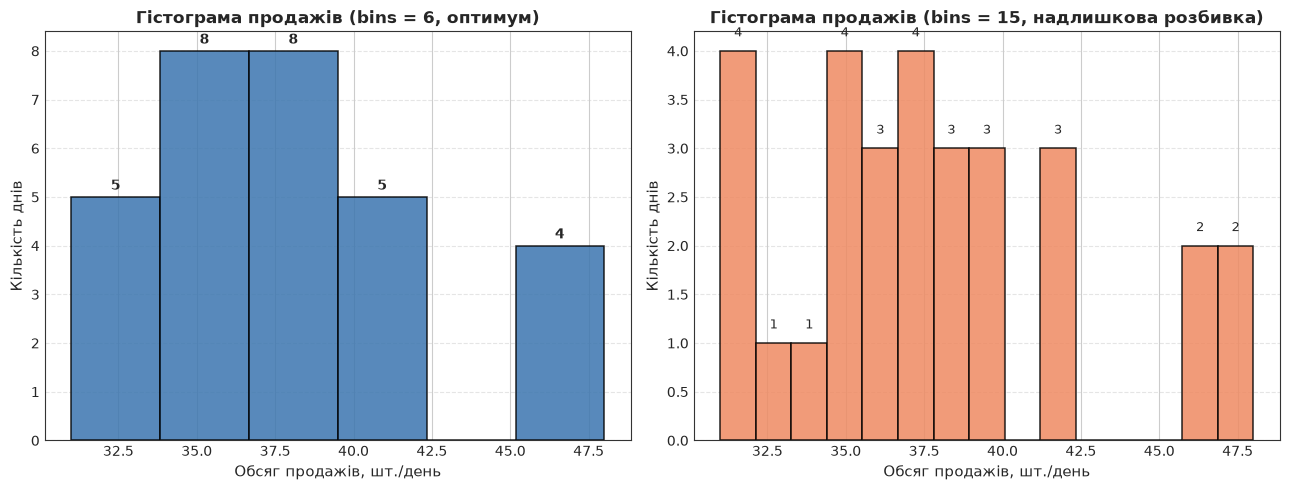

In [4]:
# Побудова двох варіантів гістограми через об'єктний інтерфейс Matplotlib
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(13, 5))

# Варіант 1: Оптимальна кількість бінів (bins = 6)
counts1, bins1, patches1 = ax1.hist(
    df["продажі"],
    bins=6,
    color="#3b75af",
    edgecolor="black",
    linewidth=1.1,
    alpha=0.85
)
ax1.set_xlabel("Обсяг продажів, шт./день", fontsize=11)
ax1.set_ylabel("Кількість днів", fontsize=11)
ax1.set_title("Гістограма продажів (bins = 6, оптимум)", fontsize=12, fontweight="bold")
ax1.grid(True, linestyle="--", alpha=0.5, axis="y")

# Додавання числових підписів частот над стовпчиками
for count, edge in zip(counts1, bins1):
    if count > 0:
        bin_center = edge + (bins1[1] - bins1[0]) / 2
        ax1.text(bin_center, count + 0.15, str(int(count)), ha="center", fontsize=10, fontweight="bold")

# Варіант 2: Завелика кількість бінів (bins = 15)
counts2, bins2, patches2 = ax2.hist(
    df["продажі"],
    bins=15,
    color="#ef8a62",
    edgecolor="black",
    linewidth=1.1,
    alpha=0.85
)
ax2.set_xlabel("Обсяг продажів, шт./день", fontsize=11)
ax2.set_ylabel("Кількість днів", fontsize=11)
ax2.set_title("Гістограма продажів (bins = 15, надлишкова розбивка)", fontsize=12, fontweight="bold")
ax2.grid(True, linestyle="--", alpha=0.5, axis="y")

# Додавання числових підписів частот над стовпчиками
for count, edge in zip(counts2, bins2):
    if count > 0:
        bin_center = edge + (bins2[1] - bins2[0]) / 2
        ax2.text(bin_center, count + 0.15, str(int(count)), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### Аналіз вибору кількості бінів (`bins`):

1. **Варіант `bins = 6` (оптимальний):**
   - Для вибірки обсягом $n = 30$ спостережень стандартні статистичні правила (зокрема правило Стерджеса $k = 1 + \log_2(n) \approx 5.9$ або правило квадратного кореня $k = \sqrt{30} \approx 5.5$) рекомендують обирати саме **5–6 інтервалів**.
   - При `bins = 6` кожен інтервал містить достатню кількість спостережень (від 2 до 10 днів), завдяки чому випадковий шум згладжується, і стає чітко видно реальну форму розподілу: основна модальна концентрація припадає на діапазон **34–38 шт./день** (типові будні дні), а в правому хвості (діапазон **42–48 шт./день**) формується окреме піднесення, сформоване підвищеним попитом у вихідні.

2. **Варіант `bins = 15` (надлишковий):**
   - При розбитті 30 спостережень на 15 інтервалів середня наповненість одного біна становить лише $30 / 15 = 2$ значення.
   - Це призводить до надмірної штучної фрагментації («ефект гребінки» або *comb effect*): з'являються порожні кишені (частота 0), декілька локальних штучних піків, і цілісна картина закономірності розподілу розпадається на хаотичні випадкові флуктуації.

**Висновок:** Для вибірки з 30 днів саме `bins = 6` надає якісну, репрезентативну та статистично обґрунтовану картину емпіричного розподілу.

## Завдання 3. Boxplot (діаграма розмаху)

Побудуємо boxplot, що порівнює розподіл щоденних продажів напоїв у будні та вихідні дні через об'єктний інтерфейс Matplotlib (`fig, ax = plt.subplots()`, `ax.boxplot()`).

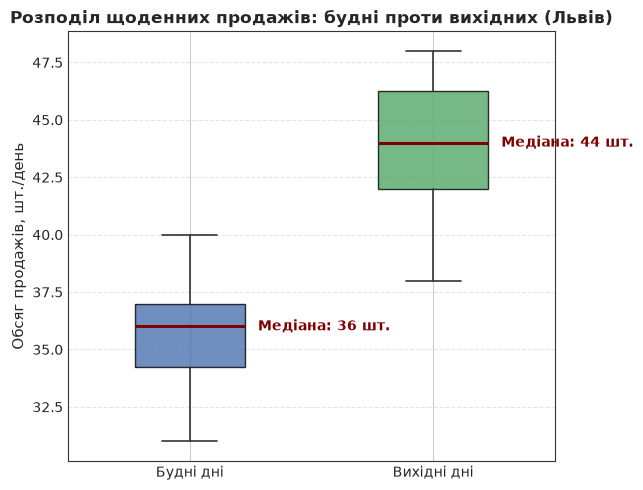

In [5]:
# Побудова діаграми розмаху (boxplot)
fig, ax = plt.subplots(figsize=(6.5, 5))

# Формування груп даних: будні та вихідні дні
groups = [
    df.loc[~df["вихідний"], "продажі"],
    df.loc[df["вихідний"], "продажі"]
]

box = ax.boxplot(
    groups,
    tick_labels=["Будні дні", "Вихідні дні"],
    patch_artist=True,
    widths=0.45,
    medianprops=dict(color="#800000", linewidth=2.2),
    whiskerprops=dict(color="#333333", linewidth=1.2),
    capprops=dict(color="#333333", linewidth=1.2),
    flierprops=dict(marker="o", color="red", alpha=0.6, markersize=6)
)

# Стилізація кольору прямокутників
colors = ["#4C72B0", "#55A868"]
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
    patch.set_edgecolor("black")

# Оформлення осей і заголовка
ax.set_ylabel("Обсяг продажів, шт./день", fontsize=11)
ax.set_title("Розподіл щоденних продажів: будні проти вихідних (Львів)", fontsize=12, fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.5, axis="y")

# Додавання числових підписів медіан безпосередньо на графіку
median_weekdays = df.loc[~df["вихідний"], "продажі"].median()
median_weekends = df.loc[df["вихідний"], "продажі"].median()
ax.text(1.28, median_weekdays, f"Медіана: {median_weekdays:.0f} шт.", color="#800000", fontweight="bold", va="center")
ax.text(2.28, median_weekends, f"Медіана: {median_weekends:.0f} шт.", color="#800000", fontweight="bold", va="center")

plt.tight_layout()
plt.show()

### Аналіз розподілу за boxplot:

1. **Порівняння мір положення (медіан):**
   - Медіана продажів у **будні дні** становить **36 шт./день** (міжквартильний розмах $Q_1 - Q_3$: від 34.25 до 37.0 шт.).
   - Медіана продажів у **вихідні дні** становить **44 шт./день** (міжквартильний розмах $Q_1 - Q_3$: від 42.0 до 46.25 шт.).
   - Приріст медіани у вихідні відносно будніх складає:
     $$\frac{44 - 36}{36} \times 100\% \approx 22.2\%$$
     що ідеально узгоджується з параметрами генерації набору в Завданні 1 (+15–25% у вихідні).

2. **Порівняння мір розсіювання (розкиду):**
   - У вихідні дні інтерквартильний розмах ($IQR = Q_3 - Q_1 = 4.25$ проти $2.75$) та повний розмах ($48 - 38 = 10$ проти $40 - 31 = 9$) є дещо ширшими, оскільки у вихідні дні потік відвідувачів сильніше варіюється залежно від погоди (температури).
   - Зверніть увагу: перший квартиль вихідних ($Q_1 = 42$) є вищим за абсолютний максимум продажів у будні дні ($\max = 40$), тобто «ящики» взагалі не перетинаються за $IQR$, що свідчить про статистично чітке й стійке розшарування продажів між буднями та вихідними.

## Завдання 4. Діаграма розсіювання (Scatter plot)

Побудуємо діаграму розсіювання через об'єктний інтерфейс Matplotlib: залежність щоденних продажів гарячих напоїв (вісь Y) від температури повітря (вісь X) за всі 30 днів.

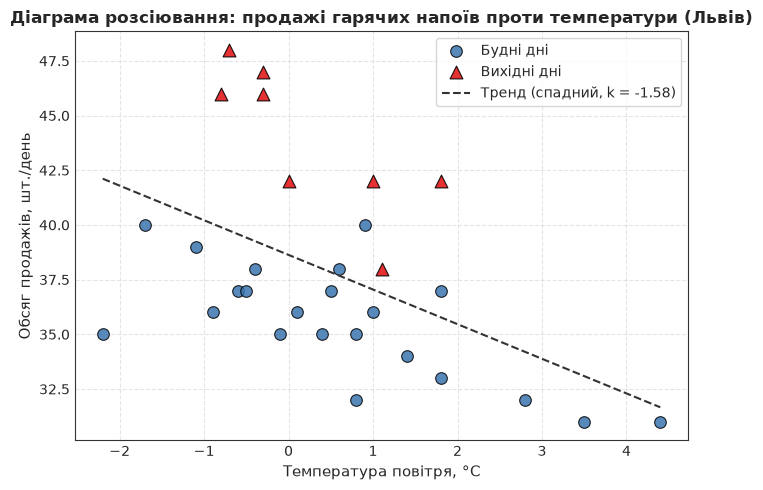

In [6]:
# Побудова діаграми розсіювання
fig, ax = plt.subplots(figsize=(7, 5))

# Відображення точок спостережень із розрізненням за типом дня
scatter_weekdays = ax.scatter(
    df.loc[~df["вихідний"], "температура"],
    df.loc[~df["вихідний"], "продажі"],
    color="#3b75af",
    edgecolor="black",
    linewidth=0.8,
    s=70,
    alpha=0.85,
    label="Будні дні"
)

scatter_weekends = ax.scatter(
    df.loc[df["вихідний"], "температура"],
    df.loc[df["вихідний"], "продажі"],
    color="#e41a1c",
    edgecolor="black",
    linewidth=0.8,
    s=85,
    marker="^",
    alpha=0.9,
    label="Вихідні дні"
)

# Лінія загального лінійного тренду для наочності зв'язку
z = np.polyfit(df["температура"], df["продажі"], 1)
p = np.poly1d(z)
x_line = np.linspace(df["температура"].min(), df["температура"].max(), 50)
ax.plot(x_line, p(x_line), color="#333333", linestyle="--", linewidth=1.5, label=f"Тренд (спадний, k = {z[0]:.2f})")

ax.set_xlabel("Температура повітря, °C", fontsize=11)
ax.set_ylabel("Обсяг продажів, шт./день", fontsize=11)
ax.set_title("Діаграма розсіювання: продажі гарячих напоїв проти температури (Львів)", fontsize=12, fontweight="bold")
ax.legend(loc="upper right", frameon=True)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Аналіз напрямку та характеру зв'язку:

1. **Напрямок зв'язку на графіку:**
   - На діаграмі розсіювання спостерігається чіткий **від'ємний (зворотний) зв'язок**: точки утворюють спадну хмару (коефіцієнт кореляції Пірсона $r \approx -0.50$ загалом та $r \approx -0.68$ у межах групи будніх днів).
   - При зниженні температури (наприклад, у морозні дні від $-2.2$ °C до $0$ °C) продажі зростають (до 40 шт. у будні та до 48 шт. у вихідні).
   - Навпаки, у тепліші дні місяця (при температурах $+3$ ... $+4.4$ °C) обсяг продажів опускається до мінімальних позначок (31–33 шт.).

2. **Відповідність специфіці товару:**
   - Для товару нашого варіанта (**гарячі напої: кава, чай, глінтвейн** у Львові при середній базовій температурі 1 °C) такий від'ємний зв'язок є цілком очікуваним і закономірним.
   - За прохолодної або мінусової температури на вулиці потреба перехожих зігрітися гарячим напоєм різко зростає, що безпосередньо стимулює продажі вуличного кіоску.

## Завдання 5. Навмисно спотворений графік (порівняння коректної та спотвореної візуалізації)

Відповідно до принципів з **Лекції 8 (частина 1)**, побудуємо через `plt.subplots(1, 2)` дві версії стовпчикової діаграми середніх продажів (будні проти вихідних):
1. **Коректний графік (ліворуч):** вісь Y починається з нуля ($0$), присутні повні підписи осей з одиницями вимірювання та заголовок.
2. **Спотворений графік (праворуч):** вісь Y штучно обрізана (починається з позначки 33, а не з 0), прибрані підписи осі Y та одиниці вимірювання — класичний приклад **«урізаного графіка» (Truncated Graph)**.

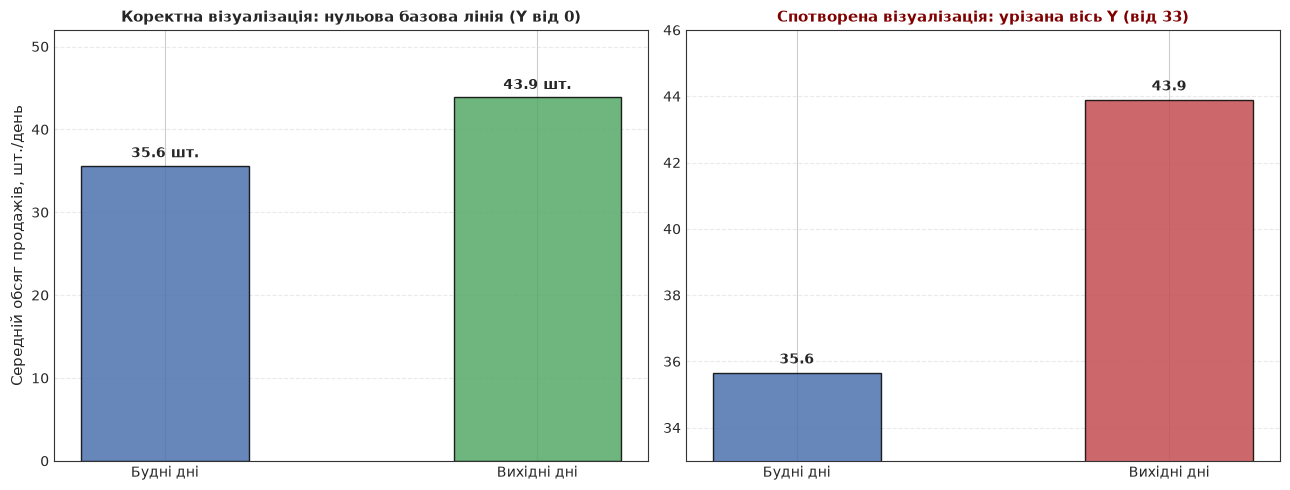

In [7]:
# Обчислення середніх продажів для порівняння
mean_weekday = df.loc[~df["вихідний"], "продажі"].mean()
mean_weekend = df.loc[df["вихідний"], "продажі"].mean()
categories = ["Будні дні", "Вихідні дні"]
values = [mean_weekday, mean_weekend]

# Побудова двох графіків поруч: коректний проти навмисно спотвореного
fig, (ax_corr, ax_dist) = plt.subplots(nrows=1, ncols=2, figsize=(13, 5))

# 1. КОРЕКТНИЙ ГРАФІК
bars_corr = ax_corr.bar(
    categories,
    values,
    color=["#4C72B0", "#55A868"],
    edgecolor="black",
    width=0.45,
    alpha=0.85
)
ax_corr.set_ylim(0, 52)
ax_corr.set_ylabel("Середній обсяг продажів, шт./день", fontsize=11)
ax_corr.set_title("Коректна візуалізація: нульова базова лінія (Y від 0)", fontsize=11, fontweight="bold")
ax_corr.grid(True, linestyle="--", alpha=0.4, axis="y")

for bar in bars_corr:
    h = bar.get_height()
    ax_corr.text(bar.get_x() + bar.get_width() / 2, h + 1.0, f"{h:.1f} шт.", ha="center", fontsize=10, fontweight="bold")

# 2. СПОТВОРЕНИЙ ГРАФІК (Truncated Y-axis)
bars_dist = ax_dist.bar(
    categories,
    values,
    color=["#4C72B0", "#C44E52"],
    edgecolor="black",
    width=0.45,
    alpha=0.85
)
# Штучне урізання осі Y: старт не з 0, а з 33!
ax_dist.set_ylim(33, 46)
# Навмисне вилучення підпису осі Y та одиниць вимірювання
ax_dist.set_ylabel("") 
ax_dist.set_title("Спотворена візуалізація: урізана вісь Y (від 33)", fontsize=11, fontweight="bold", color="#800000")
ax_dist.grid(True, linestyle="--", alpha=0.4, axis="y")

for bar in bars_dist:
    h = bar.get_height()
    ax_dist.text(bar.get_x() + bar.get_width() / 2, h + 0.3, f"{h:.1f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

### Письмовий аналіз застосованого спотворення:

1. **Яке саме спотворення з Лекції 8 застосовано:**
   - Застосовано прийом **«Урізання осі Y» (Truncated Y-Axis / Broken Baseline)** разом із **вилученням підписів осі та одиниць вимірювання**.
   - У стовпчикових діаграмах (bar charts) значення кодується **довжиною стовпчика від базової лінії**. За правилами візуалізації базова лінія для стовпчиків обов'язково має починатися з нуля ($0$).

2. **Як саме спотворення змінює сприйняття графіка (кількісний аналіз та Lie Factor):**
   - **У реальних даних:** середній продаж у будні становить $35.6$ шт., а у вихідні — $43.9$ шт. Фактична різниця становить лише $+23.1\%$ (відношення $43.88 / 35.64 = 1.23$). На лівому коректному графіку це наочно видно: стовпчик вихідних лише на чверть вищий за стовпчик будніх.
   - **На спотвореному графіку:** через обрізання осі на рівні $33$ видима геометрична висота стовпчика будніх становить лише $35.64 - 33 = 2.64$ од., тоді як видима висота стовпчика вихідних — $43.88 - 33 = 10.88$ од.
   - **Візуальний ефект:** стовпчик вихідних виглядає у $\frac{10.88}{2.64} \approx 4.12$ раза вищим (більш ніж на $+312\%$)!
   - **Фактор викривлення (Lie Factor за Едвардом Тафті):**
     $$\text{Lie Factor} = \frac{\text{Відносна зміна у візуальному зображенні}}{\text{Відносна зміна у фактичних даних}} = \frac{312.5\%}{23.1\%} \approx 13.5$$
     Значення $\text{Lie Factor} \gg 1$ свідчить про екстремальне маніпулювання зоровим сприйняттям глядача, яке створює хибне враження «колосального вибуху продажів у вихідні», хоча насправді приріст становить лише помірні 23%.

## Відповіді на контрольні / теоретичні запитання

---

### 1. Чому обрізана вісь Y на стовпчиковій діаграмі перебільшує різницю між категоріями, хоча підписані числа лишаються правильними?

**Відповідь:**
- **Психологія візуального сприйняття:** Стовпчикові діаграми (bar charts) використовують як основний графічний примітив **довжину та площу стовпчика**. Людський мозок на підсвідомому рівні оцінює співвідношення величин шляхом прямого зіставлення висот геометричних фігур відносно осі, а не шляхом читання дрібних числових міток на осі координат.
- **Математичний механізм:** Коли нульова точка осі відсікається (вісь починається, наприклад, зі значення $33$ замість $0$), з кожного стовпчика віднімається однакова абсолютна величина ($33$). При відніманні константи від двох додатних чисел їхнє арифметичне відношення різко зростає:
  $$\frac{A}{B} \ll \frac{A - C}{B - C} \quad (\text{при } A > B > C > 0)$$
  Як результат, різниця у $23\%$ між категоріями на графіку візуально трансформується у 4-кратну різницю за площею стовпчиків (фактор викривлення $\text{Lie Factor} \approx 13.5$).
- Навіть якщо числа на осі чи над стовпчиками підписані безпомилково, графік генерує потужне хибне візуальне враження, яке превалює над числовим аналізом, оскільки метою візуалізації є передача інформації через форму, а не через примус до ручних обчислень у голові.

---

### 2. Приклад, коли лінійний графік (з'єднання точок лінією) буде методологічною помилкою для категоріальних даних, і чому (з посиланням на шкали вимірювання з Лекції 4)?

**Відповідь:**
- **Шкали вимірювання (Лекція 4):** Відповідно до теорії шкал Стівенса, категоріальні дані належать до **номінальної шкали** (наприклад, перелік міст: «Львів», «Київ», «Одеса», «Харків» або типи напоїв: «Кава», «Чай», «Лимонад»). Для номінальної шкали не визначені відношення порядку ($<, >$), відстані чи інтерполяції. Категорії є дискретними, автономними та неупорядкованими якісними класами.
- **Семантика лінійного графіка:** З'єднувальна лінія в графічному синтаксисі означає **неперервність (континіум)** та відображає функціональну залежність або часовий тренд (інтервальна або відносна шкала неперервного типу, наприклад час, температура, тиск). Нахил лінії візуально читається як швидкість зміни процесу (похідна), а кожна проміжна точка на відрізку сприймається як інтерпольоване значення.
- **Методологічна помилка:** Якщо з'єднати лінією точки продажів за містами («Львів» $\rightarrow$ «Київ» $\rightarrow$ «Одеса»), виникає потрійне викривлення:
  1. *Хибна інтерполяція:* створюється ілюзія існування проміжних станів (наприклад, «півдороги між Львовом і Києвом» або «між чаєм і кавою»), що є фізичним абсурдом;
  2. *Хибний тренд:* глядач шукає закономірність спаду чи зростання там, де її немає;
  3. *Залежність від довільного порядку:* якщо довільно поміняти міста місцями на осі X, ламана лінія кардинально змінить свою форму (піки перетворяться на спади), тоді як суть даних не зміниться.
- **Правильне рішення:** Для номінальних даних слід використовувати виключно стовпчикові діаграми (`bar chart`) або точкові маркери без з'єднувальних ліній.

---

### 3. Чому підписи осей, одиниці вимірювання і заголовок — не оздоблення графіка, а частина твердження, яке він робить?

**Відповідь:**
- **Графік як самодостатній науковий вираз:** Графік — це не декоративна картинка, а структуроване твердження про властивості досліджуваної генеральної сукупності чи емпіричного процесу. Як будь-яке математичне судження, воно повинно мати суб'єкт, предикат та область визначення.
- **Заголовок:** Задає контекст дослідження — що саме зображено, на якому об'єкті, в якій локації та за який період (наприклад: *«Розподіл щоденних продажів гарячих напоїв у м. Львів за 30 днів»*). Без заголовка спостережуваний патерн позбавлений семантичної прив'язки.
- **Підписи осей:** Фіксують ролі змінних (яка змінна є незалежним предиктором / фактором на осі X, а яка — залежним відгуком на осі Y) та шкалу їх вимірювання.
- **Одиниці вимірювання:** Числові значення є абстрактними символами, поки їм не присвоєно фізичну або економічну розмірність (наприклад, $35$ — це штуки, гривні, тисячі доларів, відсотки чи градуси?). Від розмірності залежить масштаб, інтерпретація та економічні висновки.
- Без цих трьох елементів графік перетворюється на абстрактний геометричний ребус, який не несе верифіковного змісту і порушує базовий принцип відтворюваності аналізу даних.

---

### 4. Що таке chartjunk (наприклад, 3D-ефект на звичайній стовпчиковій діаграмі) і чому він шкодить, а не прикрашає сприйняття графіка?

**Відповідь:**
- **Визначення терміна:** Поняття **chartjunk** («візуальне сміття») введене класиком візуалізації даних Едвардом Тафті (Edward Tufte). Воно позначає будь-які елементи оформлення графічного простору, які не несуть корисної інформації про дані, відволікають увагу аналітика або викривляють геометрію сприйняття (псевдо-3D об'єми, декоративні текстури, градієнти, яскраві фонові малюнки, масивні рамки, важкі чорні сітки).
- **Принцип Data-Ink Ratio:** Тафті висунув фундаментальне правило мінімізації зайвого:
  $$\text{Data-Ink Ratio} = \frac{\text{Чорнило, витрачене безпосередньо на відображення даних}}{\text{Загальна кількість чорнила, витраченого на графік}} \rightarrow 1$$
  Будь-яке «неінформативне чорнило» зменшує щільність корисної інформації та розпорошує увагу.
- **Чому 3D-ефект безпосередньо шкодить:**
  1. *Оптичне викривлення масштабу:* Через перспективу об'єкти на передньому плані здаються більшими, ніж аналогічні або навіть вищі об'єкти на задньому плані.
  2. *Невизначеність точки зчитування:* У 3D-стовпчику з'являється кілька паралельних верхніх граней (переднє ребро, задня грань, середина верхнього зрізу). Глядач не знає, яка саме лінія відповідає точній позначці на шкалі осі Y, що призводить до систематичної помилки зчитування у $5–15\%$.
  3. *Когнітивне перевантаження:* Зорова кора головного мозку вимушена витрачати когнітивні ресурси на реконструкцію штучного тривимірного простору замість швидкого аналізу сутності даних.

---